0) Setup

In [1]:
pip install wfdb


Note: you may need to restart the kernel to use updated packages.


1) Load metadata + map to 5 superclasses

In [ ]:
import wfdb

# Correct path (omit .dat / .hea)
record = wfdb.rdrecord("dataset/PTBXL/records500/00000/00001_hr")

# Signal array: (samples, leads)
print("Signal shape:", record.p_signal.shape)

# First 10 samples from first lead
print(record.p_signal[:10, 0])

# Metadata
print("Sampling frequency:", record.fs)
print("Leads:", record.sig_name)


Signal shape: (5000, 12)
[-0.115 -0.115 -0.115 -0.115 -0.115 -0.115 -0.115 -0.117 -0.109 -0.108]
Sampling frequency: 500
Leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


2) Quick sanity checks (plot + missing)

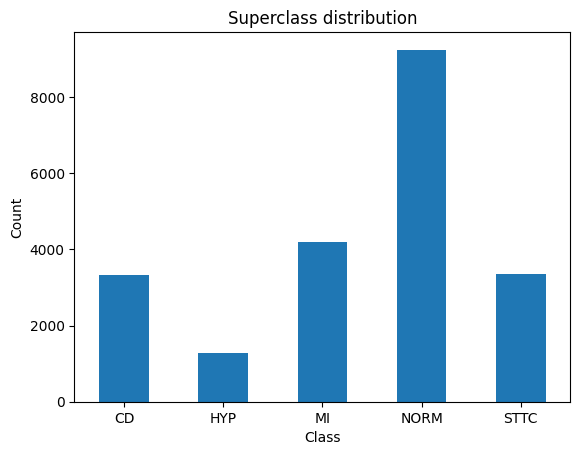

pacemaker              0.999345
electrodes_problems    0.998691
infarction_stadium2    0.995184
burst_noise            0.972835
baseline_drift         0.926174
extra_beats            0.912007
static_noise           0.850103
infarction_stadium1    0.738171
height                 0.676548
weight                 0.562091
dtype: float64

In [ ]:
import matplotlib.pyplot as plt

ax = db["y_super"].value_counts().sort_index().plot(kind="bar", rot=0, title="Superclass distribution")
ax.set_xlabel("Class"); ax.set_ylabel("Count"); plt.show()

missing_rates = db.isna().mean().sort_values(ascending=False)
missing_rates.head(10)


3) Patient-wise split (≈80/20)

In [24]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
tr_idx, te_idx = next(gss.split(db, groups=db["patient_id"]))
db_train = db.iloc[tr_idx].reset_index(drop=True)
db_test  = db.iloc[te_idx].reset_index(drop=True)
len(db_train), len(db_test)


(17080, 4308)

4) Preview one ECG (100 Hz)

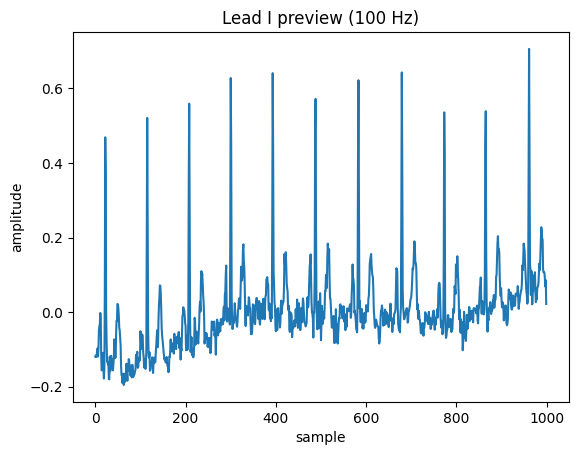

In [26]:
from pathlib import Path
import wfdb, matplotlib.pyplot as plt

rel = db_train["filename_lr"].iloc[0]                  # e.g., records100/.../_lr
rec_path = (Path("dataset/PTBXL") / rel).with_suffix("")  # wfdb path without extension
sig, _ = wfdb.rdsamp(str(rec_path))

plt.plot(sig[:,0]); plt.title("Lead I preview (100 Hz)")
plt.xlabel("sample"); plt.ylabel("amplitude"); plt.show()


5) Feature engineering (stats + coarse FFT)

In [27]:
import numpy as np, pandas as pd
from tqdm import tqdm
import wfdb
from pathlib import Path

def features_from_signal(x):  # x: (T,12)
    feats={}
    for i in range(12):
        s=x[:,i]
        feats[f"lead{i}_mean"]=float(np.mean(s))
        feats[f"lead{i}_std"]=float(np.std(s))
        feats[f"lead{i}_min"]=float(np.min(s))
        feats[f"lead{i}_max"]=float(np.max(s))
        feats[f"lead{i}_p95"]=float(np.percentile(s,95))
        feats[f"lead{i}_p05"]=float(np.percentile(s,5))
        # Coarse spectrum bands
        f=np.fft.rfft(s); p=(f*np.conj(f)).real; n=p.size
        edges=np.linspace(0,n,5,dtype=int)
        for b in range(4):
            feats[f"lead{i}_band{b}"]=float(p[edges[b]:edges[b+1]].sum())
    with np.errstate(invalid="ignore"):
        feats["interlead_corr_mean"]=float(np.nanmean(np.corrcoef(x, rowvar=False)))
    return feats

def build_features(df, filename_col="filename_lr", base="dataset/PTBXL", n_max=None):
    rows=[]
    it = df[[filename_col,"y_super"]].itertuples(index=False)
    if n_max is not None:
        it = list(it)[:n_max]
    for rel, y in tqdm(it, total=(n_max if n_max is not None else len(df))):
        rec_path = (Path(base) / rel).with_suffix("")
        sig, _ = wfdb.rdsamp(str(rec_path))
        feats = features_from_signal(sig.astype(np.float32))
        feats["y"]=y; feats["rel"]=rel
        rows.append(feats)
    return pd.DataFrame(rows)

# Set n_max to a small number (e.g., 200) for a quick first run; None = full set
N_MAX = None
feat_tr = build_features(db_train, n_max=N_MAX)
feat_te = build_features(db_test,  n_max=N_MAX)

Path("features").mkdir(exist_ok=True)
feat_tr.to_csv("features/ptbxl_train_100hz.csv", index=False)
feat_te.to_csv("features/ptbxl_test_100hz.csv", index=False)

feat_tr.shape, feat_te.shape


100%|██████████| 4308/4308 [00:32<00:00, 133.32it/s]


((17080, 123), (4308, 123))

6) Models (LR, RF, Linear SVM) + tuning

In [29]:
# === 6) MODELS (LR, RF, Linear SVM) + TUNING — best-practice ===
# - Patient-wise CV to avoid leakage
# - No deprecated 'multi_class' arg for LogisticRegression
# - Threading backend for macOS to avoid debugpy spawn issues
# - Sensible grids for quick but meaningful tuning

import numpy as np
from joblib import parallel_backend

# ---- prepare features + patient groups ----
# feat_tr, feat_te must already exist from step 5
# db_train must exist from step 3
rel2pid = dict(db_train[["filename_lr", "patient_id"]].values)
_feat = feat_tr.copy()
_feat["patient_id"] = _feat["rel"].map(rel2pid)

Xtr = _feat.drop(columns=["y","rel","patient_id"])
ytr = _feat["y"]
groups = _feat["patient_id"].values

Xte = feat_te.drop(columns=["y","rel"])
yte = feat_te["y"]

# ---- group-aware CV (prefer StratifiedGroupKFold; fallback to GroupKFold) ----
try:
    from sklearn.model_selection import StratifiedGroupKFold
    cv_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    cv_kwargs = {"groups": groups}
except Exception:
    from sklearn.model_selection import GroupKFold
    cv_splitter = GroupKFold(n_splits=5)
    cv_kwargs = {"groups": groups}

# ---- models ----
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Logistic Regression (multinomial handled automatically by lbfgs)
lr_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"))
])

# Random Forest (nonlinear tabular baseline)
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced_subsample", random_state=42, n_jobs=-1
)

# Linear SVM (often very strong on these stats/FFT features)
svm_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("clf", LinearSVC(class_weight="balanced", max_iter=5000))
])

# ---- grids ----
from sklearn.model_selection import GridSearchCV

grid_lr = {"clf__C": [0.1, 1, 3]}
grid_rf = {"n_estimators": [200, 400], "max_depth": [None, 20, 40]}
grid_svm = {"clf__C": [0.5, 1, 2]}  # quick sweep; expand if you want

# ---- run tuning (threading backend; avoids subprocess issues on Mac) ----
with parallel_backend("threading", n_jobs=-1):
    gs_lr = GridSearchCV(
        lr_pipe, grid_lr, cv=cv_splitter, scoring="f1_macro", n_jobs=-1, refit=True
    ).fit(Xtr, ytr, **cv_kwargs)

with parallel_backend("threading", n_jobs=-1):
    gs_rf = GridSearchCV(
        rf, grid_rf, cv=cv_splitter, scoring="f1_macro", n_jobs=-1, refit=True
    ).fit(Xtr, ytr, **cv_kwargs)

with parallel_backend("threading", n_jobs=-1):
    gs_svm = GridSearchCV(
        svm_pipe, grid_svm, cv=cv_splitter, scoring="f1_macro", n_jobs=-1, refit=True
    ).fit(Xtr, ytr, **cv_kwargs)

best_lr   = gs_lr.best_estimator_
best_rf   = gs_rf.best_estimator_
best_svm  = gs_svm.best_estimator_
cv_scores = {
    "LR_f1_macro":  gs_lr.best_score_,
    "RF_f1_macro":  gs_rf.best_score_,
    "SVM_f1_macro": gs_svm.best_score_,
}
best_params = {
    "LR":  gs_lr.best_params_,
    "RF":  gs_rf.best_params_,
    "SVM": gs_svm.best_params_,
}

cv_scores, best_params


/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


({'LR_f1_macro': np.float64(0.5173684083448677),
  'RF_f1_macro': np.float64(0.5338223965722146),
  'SVM_f1_macro': np.float64(0.51749083395153)},
 {'LR': {'clf__C': 3},
  'RF': {'max_depth': 20, 'n_estimators': 400},
  'SVM': {'clf__C': 1}})

7) Evaluation (metrics + confusion matrix)

In [30]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import numpy as np

def evaluate(model, X, y):
    yp = model.predict(X)
    acc = accuracy_score(y, yp)
    macro_f1 = f1_score(y, yp, average="macro")
    report = classification_report(y, yp, digits=4)
    auc = None
    try:
        scores = model.predict_proba(X) if hasattr(model, "predict_proba") else model.decision_function(X)
        lb = LabelBinarizer().fit(y)
        auc = roc_auc_score(lb.transform(y), scores, average="macro", multi_class="ovr")
    except Exception:
        pass
    return {"y_pred": yp, "acc": acc, "macro_f1": macro_f1, "report": report, "auc": auc}

eval_lr  = evaluate(best_lr,  Xte, yte)
eval_rf  = evaluate(best_rf,  Xte, yte)
eval_svm = evaluate(best_svm, Xte, yte)

{"LR": {"acc": eval_lr["acc"], "macro_f1": eval_lr["macro_f1"], "auc": eval_lr["auc"]},
 "RF": {"acc": eval_rf["acc"], "macro_f1": eval_rf["macro_f1"], "auc": eval_rf["auc"]},
 "SVM":{"acc": eval_svm["acc"],"macro_f1": eval_svm["macro_f1"],"auc": eval_svm["auc"]}}


{'LR': {'acc': 0.590297121634169,
  'macro_f1': 0.5406495746466996,
  'auc': 0.835282847983762},
 'RF': {'acc': 0.6450789229340761,
  'macro_f1': 0.5582111306694715,
  'auc': 0.8721842563200246},
 'SVM': {'acc': 0.6142061281337048,
  'macro_f1': 0.5400886465083282,
  'auc': 0.8324833729216093}}

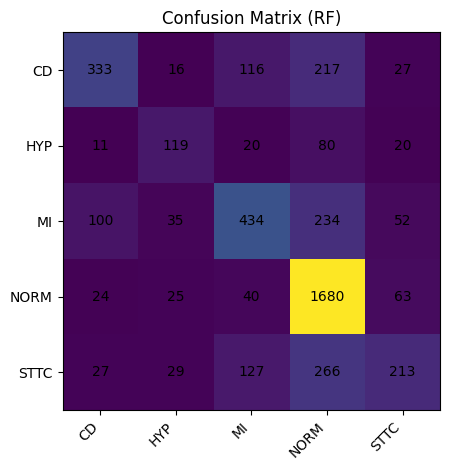

('RF',
 '              precision    recall  f1-score   support\n\n          CD     0.6727    0.4697    0.5532       709\n         HYP     0.5312    0.4760    0.5021       250\n          MI     0.5889    0.5076    0.5452       855\n        NORM     0.6782    0.9170    0.7798      1832\n        STTC     0.5680    0.3218    0.4108       662\n\n    accuracy                         0.6451      4308\n   macro avg     0.6078    0.5384    0.5582      4308\nweighted avg     0.6341    0.6451    0.6231      4308\n')

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

best_name, best_eval = max([("LR",eval_lr),("RF",eval_rf),("SVM",eval_svm)], key=lambda kv: kv[1]["macro_f1"])
classes = sorted(ytr.unique())
yhat = {"LR":eval_lr["y_pred"], "RF":eval_rf["y_pred"], "SVM":eval_svm["y_pred"]}[best_name]

cm = confusion_matrix(yte, yhat, labels=classes)
plt.imshow(cm); plt.title(f"Confusion Matrix ({best_name})")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right"); plt.yticks(range(len(classes)), classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout(); plt.show()

best_name, best_eval["report"]


8) Federated learning (FedAvg proxy on LR; 4 clients)

In [32]:
import numpy as np
from copy import deepcopy
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Map training features to patient IDs
rel2pid = dict(db_train[["filename_lr","patient_id"]].values)
feat_tr_fl = feat_tr.copy()
feat_tr_fl["patient_id"] = feat_tr_fl["rel"].map(rel2pid)

K = 4
clients = np.array_split(db_train["patient_id"].drop_duplicates().sample(frac=1, random_state=42).values, K)
client_feats = [
    feat_tr_fl[feat_tr_fl["patient_id"].isin(p)].drop(columns=["patient_id"]).reset_index(drop=True)
    for p in clients
]

def fit_lr_fd(fd):
    X=fd.drop(columns=["y","rel"]); y=fd["y"]
    m=Pipeline([("scaler", StandardScaler(with_mean=False)),
                ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", multi_class="ovr"))])
    m.fit(X,y); return m

client_models = [fit_lr_fd(fd) for fd in client_feats]
coefs = np.stack([m.named_steps["clf"].coef_ for m in client_models]).mean(axis=0)
ints  = np.stack([m.named_steps["clf"].intercept_ for m in client_models]).mean(axis=0)

fed = deepcopy(client_models[0])
fed.named_steps["clf"].coef_ = coefs
fed.named_steps["clf"].intercept_ = ints

fed_macro_f1  = f1_score(yte, fed.predict(Xte), average="macro")
cent_macro_f1 = eval_lr["macro_f1"]
{"FedAvg_macro_f1": fed_macro_f1, "Centralized_LR_macro_f1": cent_macro_f1}


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_clas

{'FedAvg_macro_f1': 0.5436361266789931,
 'Centralized_LR_macro_f1': 0.5406495746466996}

9) Interpretation (feature importance)

In [33]:
import pandas as pd, numpy as np

# LR: mean |coef| across classes
lr_coef_mag = np.mean(np.abs(best_lr.named_steps["clf"].coef_), axis=0)
pd.Series(lr_coef_mag, index=Xtr.columns).sort_values(ascending=False).head(20)


lead11_mean     0.801827
lead6_std       0.656725
lead3_std       0.644779
lead1_std       0.640570
lead8_std       0.629376
lead0_std       0.622300
lead11_band0    0.583095
lead9_band0     0.561023
lead5_std       0.459785
lead6_p05       0.447093
lead5_max       0.402847
lead0_max       0.400507
lead2_std       0.395753
lead7_band0     0.385428
lead4_p95       0.384857
lead10_std      0.380267
lead0_p95       0.379432
lead6_band0     0.349982
lead9_std       0.347478
lead6_p95       0.347434
dtype: float64

In [34]:
# RF: feature importances
pd.Series(best_rf.feature_importances_, index=Xtr.columns).sort_values(ascending=False).head(20)


lead10_max             0.021842
lead3_min              0.018209
lead3_p05              0.017899
interlead_corr_mean    0.017432
lead10_band1           0.015886
lead9_p95              0.015233
lead3_band1            0.015096
lead10_p95             0.015045
lead1_max              0.014885
lead6_min              0.014799
lead11_max             0.014452
lead10_std             0.014392
lead8_p95              0.012323
lead11_band1           0.011745
lead6_band1            0.011629
lead2_min              0.011307
lead9_max              0.011276
lead10_band0           0.011044
lead5_min              0.010730
lead6_band0            0.010620
dtype: float64

10) Ethics & sustainability checks

In [35]:
from sklearn.metrics import f1_score

def subgroup_f1(df_feats, y_true, y_pred, meta_df, key="sex"):
    j = meta_df[["filename_lr", key]].merge(df_feats[["rel"]], left_on="filename_lr", right_on="rel", how="right")
    out={}
    for v in sorted(j[key].dropna().unique()):
        m = (j[key]==v).values
        out[str(v)] = f1_score(np.array(y_true)[m], np.array(y_pred)[m], average="macro")
    return out

best_pred = {"LR":eval_lr["y_pred"], "RF":eval_rf["y_pred"], "SVM":eval_svm["y_pred"]}[best_name]
subgroup_f1(feat_te, yte, best_pred, db_test, key="sex")


{'0': 0.5642375051291724, '1': 0.5422008169474717}

In [36]:
import time, os, pickle
t0=time.time(); _=best_rf.predict(Xte); infer_time=time.time()-t0
os.makedirs("models", exist_ok=True)
with open("models/best_rf.pkl","wb") as f: pickle.dump(best_rf,f)
size_mb = os.path.getsize("models/best_rf.pkl")/1e6
{"rf_infer_time_s": round(infer_time,3), "rf_model_size_mb": round(size_mb,2)}


{'rf_infer_time_s': 0.135, 'rf_model_size_mb': 252.11}